# Erkennung der Schweißqualität während des Schweißprozesses

## Entwicklung eines datengetriebenen Verfahrens zur Überwachung und Vorhersage der Schweißqualität anhand von induktiven Tasterdaten und thermischen LWIR-Aufnahmen

In [125]:
from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from PIL import Image
import math

## Hypothese:

#### Die Taster-Zeitreihen können genutzt werden, um typische Muster der `Fügespaltentwicklung` abzuleiten.

## Taster-Zeitreihen analysieren:
- `Wie bewegt sich das bewegliche Blech während einer Schweißung?`
- `Wie unterscheidet sich diese Bewegung entlang des Blechs bei Taster 1, 2 und 3?`
- `Welche Bewegungsmuster könnte auf eine stärkere Fügespaltentwicklung hindeuten?`

#### Wie bewegen sich Taster 1, 2 und 3 während einer Schweißung (Konfiguration 001)?

In [126]:
# Betrachtung: 001-000 (Preprocessed)

pfad001_000Prep = Path("../data/Dataset/Preprocessed/Inductiv_Probes/001/001-000.npy")

fuerDataFrame = np.load(pfad001_000Prep)

df001_000Prep = pd.DataFrame(
    {
        "Time (s)": fuerDataFrame[0],
        "Taster 1 (mm)": fuerDataFrame[1],
        "Taster 2 (mm)": fuerDataFrame[2],
        "Taster 3 (mm)": fuerDataFrame[3]
    }
)

display(df001_000Prep[: 100])

print(df001_000Prep.shape)

,Time (s),Taster 1 (mm),Taster 2 (mm),Taster 3 (mm)
0,1.134,0.020373,0.012720,0.003004
1,1.135,0.020452,0.012877,0.003161
2,1.136,0.020530,0.013034,0.003396
3,1.137,0.020687,0.013270,0.003553
4,1.138,0.020530,0.013505,0.003710
...,...,...,...,...
95,1.229,0.032382,0.051413,0.069559
96,1.230,0.032539,0.051806,0.070501
97,1.231,0.032539,0.052198,0.071050
98,1.232,0.032853,0.052905,0.071757


(19909, 4)


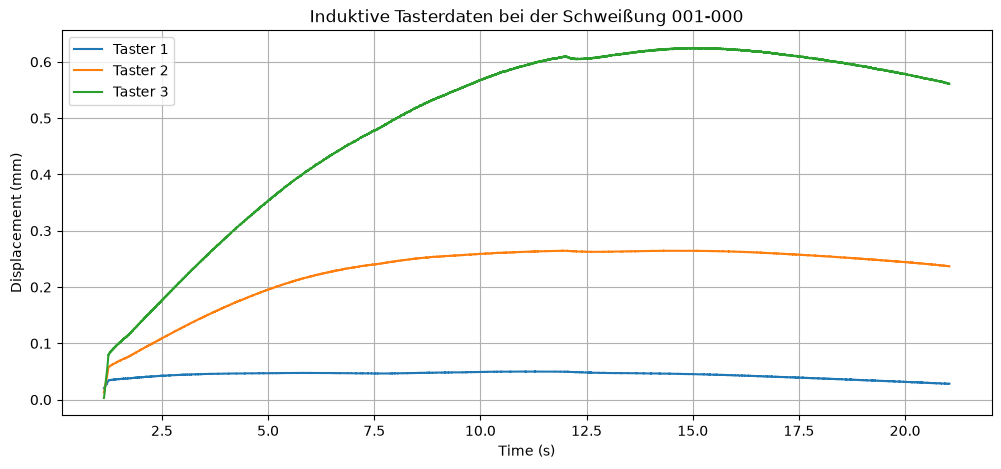

In [127]:
plt.figure(figsize = (12, 5))

plt.plot(df001_000Prep["Time (s)"], df001_000Prep["Taster 1 (mm)"], label="Taster 1")
plt.plot(df001_000Prep["Time (s)"], df001_000Prep["Taster 2 (mm)"], label="Taster 2")
plt.plot(df001_000Prep["Time (s)"], df001_000Prep["Taster 3 (mm)"], label="Taster 3")

plt.xlabel("Time (s)")
plt.ylabel("Displacement (mm)")
plt.title("Induktive Tasterdaten bei der Schweißung 001-000")
plt.legend()
plt.grid()

plt.show()

##### -> Starke Positionsänderungen in Y-Richtung vor allem bei Taster 3. Taster 3 befindet sich an der rechten bzw. endseitigen Messposition des beweglichen Blechs.

#### Und wenn man alle 50 Schweißungen vergleicht innerhalb der Konfiguration 001?

##### Problem:

In [128]:
pfad000Prep = Path("../data/Dataset/Preprocessed/Inductiv_Probes/001/001-000.npy")
pfad015Prep = Path("../data/Dataset/Preprocessed/Inductiv_Probes/001/001-015.npy")

daten000 = np.load(pfad000Prep)
daten015 = np.load(pfad015Prep)

print("001-000 Shape:", daten000.shape)
print("001-015 Shape:", daten015.shape)

001-000 Shape: (4, 19909)
001-015 Shape: (3, 19280)


In [129]:
df000Prep = pd.DataFrame(daten000.T)
df015Prep = pd.DataFrame(daten015.T)

print("001-000:")
display(df000Prep.head(5))

print("001-015:")
display(df015Prep.head(5))

001-000:


,0,1,2,3
0,1.134,0.020373,0.012720,0.003004
1,1.135,0.020452,0.012877,0.003161
2,1.136,0.020530,0.013034,0.003396
3,1.137,0.020687,0.013270,0.003553
4,1.138,0.020530,0.013505,0.003710


001-015:


,0,1,2
0,-0.000094,-0.000060,-0.000037
1,-0.000173,-0.000060,-0.000115
2,-0.000251,-0.000060,-0.000115
3,-0.000173,0.000018,-0.000037
4,-0.000094,-0.000138,-0.000115


##### Shape hat sich verändert ab 015, kein Zeitstempel vorhanden. Bei der Konfiguration 001 hat man auf die ersten 15 einen Zeitstempel und danach nicht mehr.

##### Andere Vorgehensweise um die 50 Schweißungen miteinander zu vergleichen aus Konfiguration 001.

#### Konfiguration 002 hat auch das gleiche Problem?

In [130]:
pfad001Prep = Path("../data/Dataset/Preprocessed/Inductiv_Probes/001")
pfad002Prep = Path("../data/Dataset/Preprocessed/Inductiv_Probes/002")

print("001 Shape Kontrolle der .npy Dateien:")
print()

for datei in sorted(pfad001Prep.glob("*.npy")):
    daten = np.load(datei)
    print(datei.name, daten.shape)

print()
print("002 Shape Kontrolle der .npy Dateien:")
print()

for datei in sorted(pfad002Prep.glob("*.npy")):
    daten = np.load(datei)
    print(datei.name, daten.shape)

001 Shape Kontrolle der .npy Dateien:

001-000.npy (4, 19909)
001-001.npy (4, 19496)
001-002.npy (4, 19762)
001-003.npy (4, 19588)
001-004.npy (4, 19833)
001-005.npy (4, 19933)
001-006.npy (4, 19660)
001-007.npy (4, 19887)
001-008.npy (4, 19869)
001-009.npy (4, 19126)
001-010.npy (4, 19916)
001-011.npy (4, 19516)
001-012.npy (4, 19801)
001-013.npy (4, 19816)
001-014.npy (4, 19852)
001-015.npy (3, 19280)
001-016.npy (3, 19280)
001-017.npy (3, 19280)
001-018.npy (3, 19280)
001-019.npy (3, 19280)
001-020.npy (3, 19280)
001-021.npy (3, 19280)
001-022.npy (3, 19280)
001-023.npy (3, 19280)
001-024.npy (3, 19279)
001-025.npy (3, 19279)
001-026.npy (3, 19280)
001-027.npy (3, 19280)
001-028.npy (3, 19280)
001-029.npy (3, 19280)
001-030.npy (3, 19279)
001-031.npy (3, 19279)
001-032.npy (3, 19279)
001-033.npy (3, 19280)
001-034.npy (3, 19280)
001-035.npy (3, 19280)
001-036.npy (3, 19280)
001-037.npy (3, 19280)
001-038.npy (3, 19280)
001-039.npy (3, 19280)
001-040.npy (3, 19280)
001-041.npy (3, 19

##### Beide Konfigurationen haben ab 015 Shape (3, n).

##### -> Bei Shape (3, n) wird die extra Zeitstempel-Spalte künstlich erzeugt um Shape zu erweitern, mithilfe von arange().

In [131]:
alleDataFrames001 = []

for datei in sorted(pfad001Prep.glob("*.npy")):

    daten = np.load(datei).T

    if daten.shape[1] == 4:

        df = pd.DataFrame(
            daten,
            columns = [
                "Time (s)",
                "Taster 1 (mm)",
                "Taster 2 (mm)",
                "Taster 3 (mm)"
            ]
        )

        df["Time Type"] = "original"

    elif daten.shape[1] == 3:

        df = pd.DataFrame(
            daten,
            columns = [
                "Taster 1 (mm)",
                "Taster 2 (mm)",
                "Taster 3 (mm)"
            ]
        )

        df["Time (s)"] = np.arange(len(df)) / 1000
        df["Time Type"] = "reconstructed"

    df["ID"] = datei.stem

    df = df[ # Reihenfolge ändern
        [
            "ID",
            "Time (s)",
            "Time Type",
            "Taster 1 (mm)",
            "Taster 2 (mm)",
            "Taster 3 (mm)"
        ]
    ]

    alleDataFrames001.append(df)

dataFrameAlleDataFrames001 = pd.concat(alleDataFrames001, ignore_index = True)

display(dataFrameAlleDataFrames001.head(5))
print("Shape: ", dataFrameAlleDataFrames001.shape)

,ID,Time (s),Time Type,Taster 1 (mm),Taster 2 (mm),Taster 3 (mm)
0,001-000,1.134,original,0.020373,0.012720,0.003004
1,001-000,1.135,original,0.020452,0.012877,0.003161
2,001-000,1.136,original,0.020530,0.013034,0.003396
3,001-000,1.137,original,0.020687,0.013270,0.003553
4,001-000,1.138,original,0.020530,0.013505,0.003710


Shape:  (970757, 6)


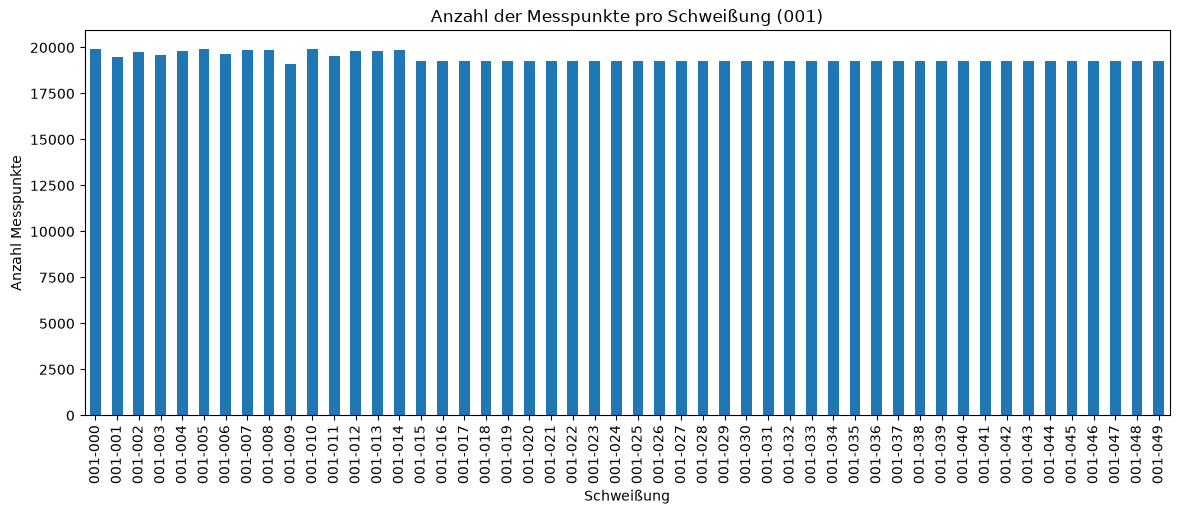

In [132]:
messpunkteProWelding = dataFrameAlleDataFrames001.groupby("ID").size()


plt.figure(figsize = (14, 5))

messpunkteProWelding.plot(kind = "bar")

plt.xlabel("Schweißung")
plt.ylabel("Anzahl Messpunkte")
plt.title("Anzahl der Messpunkte pro Schweißung (001)")
plt.show()

#### Um das typische Bewegungsverhalten des beweglichen Blechs zu untersuchen, werden alle 50 Schweißungen der Konfiguration 001 miteinander verglichen.

#### Da die einzelnen Schweißungen unterschiedlich viele Messpunkte enthalten, ist es nötig die Taster-Zeitreihen zunächst auf eine bestimmte Anzahl an relativer Positionen zwischen 0 % und 100 % des Schweißverlaufs zu interpolieren, zum Beispiel auf 200 Positionen.

#### Anschließend soll für jede relative Position der Median der Tasterwerte über alle 50 Schweißungen berechnet werden.

#### Zusätzlich wird das 25%- und 75%-Quantil bestimmt. Der Bereich zwischen Q25 und Q75 beinhaltet die mittleren 50 % der Schweißungen und zeigt damit, wie stark die Tasterwerte zwischen den einzelnen Schweißungen streuen.

#### Die Analyse wird separat für Taster 1, Taster 2 und Taster 3 durchgeführt.

In [133]:
anzahlMesswerte = 200

verlaufTaster1 = []
verlaufTaster2 = []
verlaufTaster3 = []

# Beispiel: id = "001-000", gruppe = DataFrame mit allen Zeilen von 001-000

for id, gruppe in dataFrameAlleDataFrames001.groupby("ID"):

    # Jede Schweißung mit sehr vielen & unterschiedlichen Messpunkten wird auf genau 200 vergleichbare Postionen gebracht

    alt = np.linspace(0, 1, len(gruppe))
    neu = np.linspace(0, 1, anzahlMesswerte)

    taster1Interpoliert = np.interp(
        neu,
        alt,
        gruppe["Taster 1 (mm)"]
    )

    taster2Interpoliert = np.interp(
        neu,
        alt,
        gruppe["Taster 2 (mm)"]
    )

    taster3Interpoliert = np.interp(
        neu,
        alt,
        gruppe["Taster 3 (mm)"]
    )

    verlaufTaster1.append(taster1Interpoliert)
    verlaufTaster2.append(taster2Interpoliert)
    verlaufTaster3.append(taster3Interpoliert)

In [134]:
verlaufTaster1 = np.array(verlaufTaster1)
verlaufTaster2 = np.array(verlaufTaster2)
verlaufTaster3 = np.array(verlaufTaster3)

print(verlaufTaster1.shape)
print(verlaufTaster2.shape)
print(verlaufTaster3.shape)

(50, 200)
(50, 200)
(50, 200)


In [135]:
medianVerlaufTaster1 = np.median(verlaufTaster1, axis = 0)
medianVerlaufTaster2 = np.median(verlaufTaster2, axis = 0)
medianVerlaufTaster3 = np.median(verlaufTaster3, axis = 0)

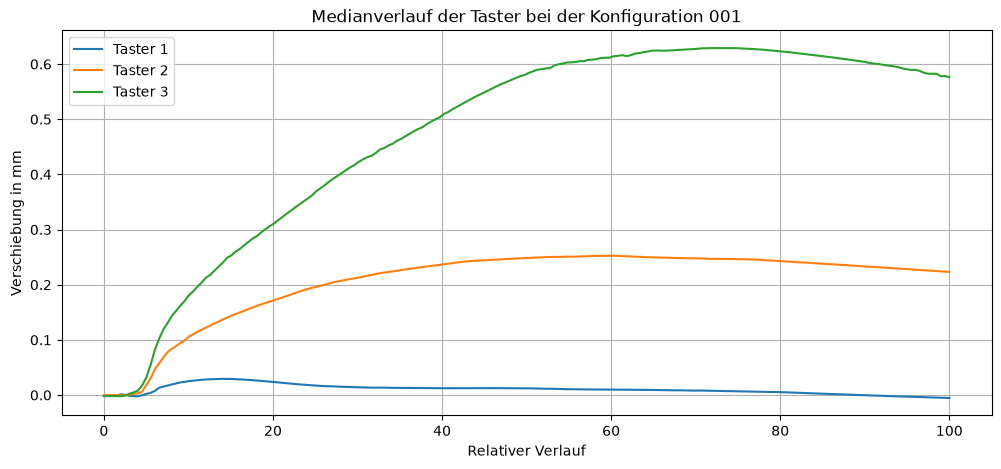

In [136]:
xAchse = np.linspace(0, 100, anzahlMesswerte) # Relativer Verlauf

plt.figure(figsize = (12, 5))

plt.plot(xAchse, medianVerlaufTaster1, label = "Taster 1")
plt.plot(xAchse, medianVerlaufTaster2, label = "Taster 2")
plt.plot(xAchse, medianVerlaufTaster3, label = "Taster 3")

plt.xlabel("Relativer Verlauf")
plt.ylabel("Verschiebung in mm")
plt.title("Medianverlauf der Taster bei der Konfiguration 001")
plt.legend()
plt.grid()
plt.show()

In [137]:
q25Taster1 = np.quantile(verlaufTaster1, 0.25, axis = 0)
q75Taster1 = np.quantile(verlaufTaster1, 0.75, axis = 0)

q25Taster2 = np.quantile(verlaufTaster2, 0.25, axis = 0)
q75Taster2 = np.quantile(verlaufTaster2, 0.75, axis = 0)

q25Taster3 = np.quantile(verlaufTaster3, 0.25, axis = 0)
q75Taster3 = np.quantile(verlaufTaster3, 0.75, axis = 0)

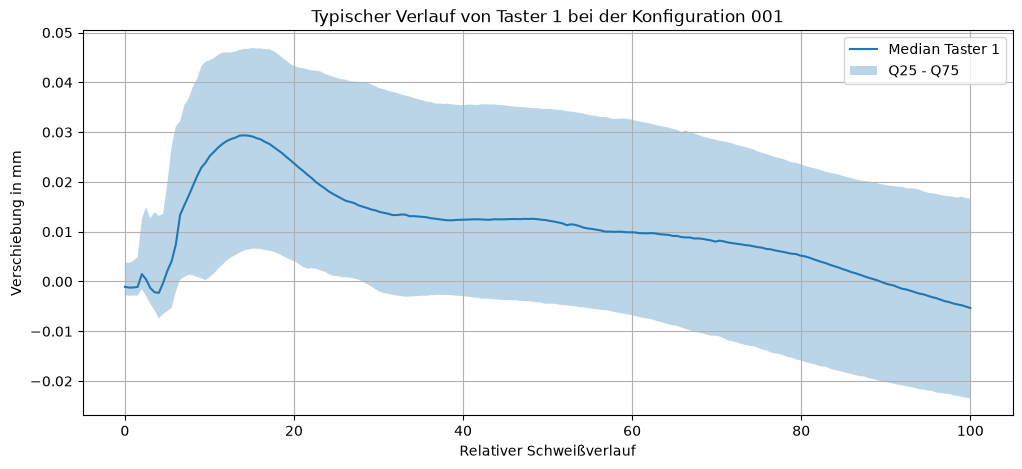

In [138]:
plt.figure(figsize = (12, 5))

plt.plot(
    xAchse,
    medianVerlaufTaster1,
    label = "Median Taster 1"
)

plt.fill_between(
    xAchse,
    q25Taster1,
    q75Taster1,
    alpha = 0.3,
    label = "Q25 - Q75"
)

plt.xlabel("Relativer Schweißverlauf")
plt.ylabel("Verschiebung in mm")
plt.title("Typischer Verlauf von Taster 1 bei der Konfiguration 001")
plt.legend()
plt.grid()

plt.show()

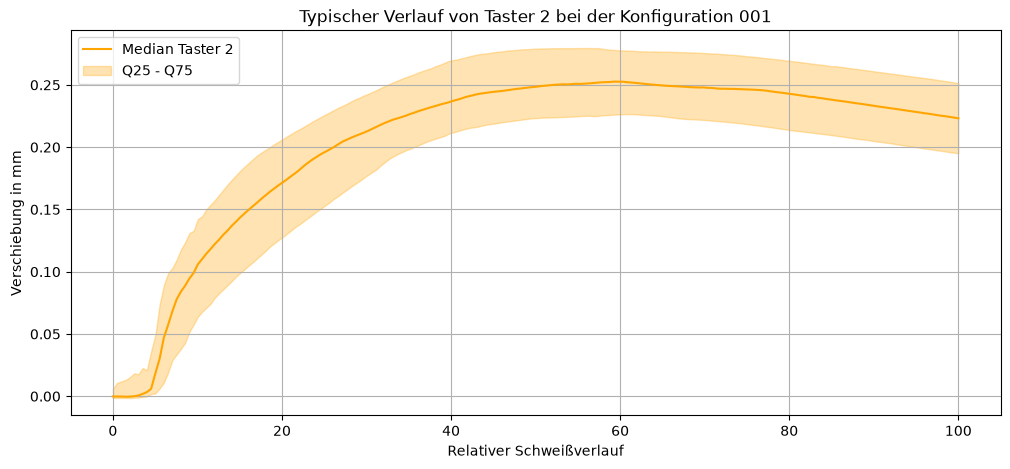

In [139]:
plt.figure(figsize = (12, 5))

plt.plot(
    xAchse,
    medianVerlaufTaster2,
    color = "orange",
    label = "Median Taster 2"
)

plt.fill_between(
    xAchse,
    q25Taster2,
    q75Taster2,
    color = "orange",
    alpha = 0.3,
    label = "Q25 - Q75"
)

plt.xlabel("Relativer Schweißverlauf")
plt.ylabel("Verschiebung in mm")
plt.title("Typischer Verlauf von Taster 2 bei der Konfiguration 001")
plt.legend()
plt.grid()

plt.show()

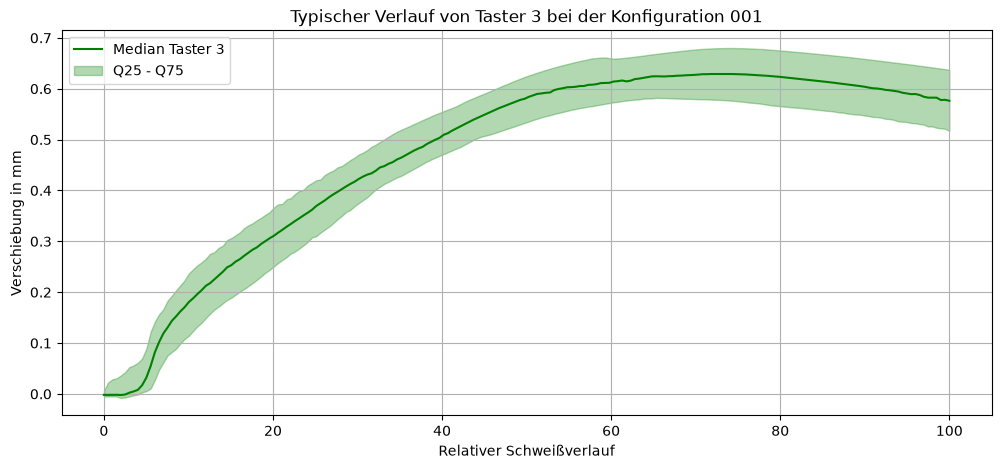

In [140]:
plt.figure(figsize = (12, 5))

plt.plot(
    xAchse,
    medianVerlaufTaster3,
    color = "green",
    label = "Median Taster 3"
)

plt.fill_between(
    xAchse,
    q25Taster3,
    q75Taster3,
    color = "green",
    alpha = 0.3,
    label = "Q25 - Q75"
)

plt.xlabel("Relativer Schweißverlauf")
plt.ylabel("Verschiebung in mm")
plt.title("Typischer Verlauf von Taster 3 bei der Konfiguration 001")
plt.legend()
plt.grid()

plt.show()

##### Die Medianverläufe zeigen, dass sich das bewegliche Blech an den drei Tasterpositionen unterschiedlich stark in Y-Richtung bewegt. Das erkennt man aber auch an der jeweiligen Y-Achse bei den 3 Diagrammen, wo auch die Q-Bereiche sichtbar sind.

##### Bei allen drei Tastern steigt die Verschiebung zunächst an und gegen Ende des Schweißverlaufs nehmen die Medianwerte ab, was auf eine Rückbewegung des Blechs hindeutet. Dies deutet darauf hin, dass sich das bewegliche Blech während des Schweißprozesses aufgrund der thermischen Belastung zunehmend bewegt und sich verformt.

##### Das Q25-Q75-Streuungsband scheint bei Taster 3 am schmalsten zu sein im Verhältnis zum Medianverlauf und deutet deshalb bei sich am meisten auf ein ähnlicheres Bewegungsverhalten.

#### Das gleiche bei der Konfiguration 002:

##### Betrachten wir zuerst die erste Schweißung von 002 als DataFrame:

In [141]:
Pfad002_000 = Path("../data/Dataset/Preprocessed/Inductiv_Probes/002/002-000.npy")

data = np.load(Pfad002_000)

dataFrame002_000 = pd.DataFrame(
    data
)

display(dataFrame002_000[: 5].T)

,0,1,2,3
0,0.346,-0.013442,0.002410,0.015417
1,0.347,-0.013442,0.002410,0.015417
2,0.348,-0.013442,0.002410,0.015339
3,0.349,-0.013364,0.002488,0.015260
4,0.350,-0.013521,0.002488,0.015574
...,...,...,...,...
3776,4.122,-0.006457,0.079168,0.177254
3777,4.123,-0.006378,0.079168,0.177332
3778,4.124,-0.006457,0.079090,0.177332
3779,4.125,-0.006300,0.079090,0.177097


In [142]:
alleDataFrames002 = []

for datei in sorted(pfad002Prep.glob("*.npy")):
    daten = np.load(datei).T

    if daten.shape[1] == 4:

        df = pd.DataFrame(
            daten,
            columns = [
                "Time (s)",
                "Taster 1 (mm)",
                "Taster 2 (mm)",
                "Taster 3 (mm)"
            ]
        )

        df["Time Type"] = "original"

    elif daten.shape[1] == 3:

        df = pd.DataFrame(
            daten,
            columns = [
                "Taster 1 (mm)",
                "Taster 2 (mm)",
                "Taster 3 (mm)"
            ]
        )

        df["Time (s)"] = np.arange(len(df)) / 1000
        df["Time Type"] = "reconstructed"

    df["ID"] = datei.stem

    df = df[
        [
            "ID",
            "Time (s)",
            "Time Type",
            "Taster 1 (mm)",
            "Taster 2 (mm)",
            "Taster 3 (mm)"
        ]
    ]

    alleDataFrames002.append(df)

dataFrameAlleDataFrames002 = pd.concat(alleDataFrames002, ignore_index = True)

display(dataFrameAlleDataFrames002.head(5))
print("Shape: ", dataFrameAlleDataFrames002.shape)

,ID,Time (s),Time Type,Taster 1 (mm),Taster 2 (mm),Taster 3 (mm)
0,002-000,0.346,original,-0.013442,0.002410,0.015417
1,002-000,0.347,original,-0.013442,0.002410,0.015417
2,002-000,0.348,original,-0.013442,0.002410,0.015339
3,002-000,0.349,original,-0.013364,0.002488,0.015260
4,002-000,0.350,original,-0.013521,0.002488,0.015574


Shape:  (205505, 6)
